## Housing Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [30]:
## Load dataset
df=pd.read_csv("/Users/mac/Desktop/Machine Learning/datasets/housing_train.csv")

print("Shape:", df.shape)
print("First 5 rows:", print(df.head()))
print("Column names:", df.columns)
print("Info:", df.info())
print("Summary:", df.describe())

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [31]:
# Unique values
print("\nColumns with unusual distribution or outliers:")
for col in df.columns:
    print(f"Number of unique values in {col}: {df[col].nunique()}")


Columns with unusual distribution or outliers:
Number of unique values in Id: 1460
Number of unique values in MSSubClass: 15
Number of unique values in MSZoning: 5
Number of unique values in LotFrontage: 110
Number of unique values in LotArea: 1073
Number of unique values in Street: 2
Number of unique values in Alley: 2
Number of unique values in LotShape: 4
Number of unique values in LandContour: 4
Number of unique values in Utilities: 2
Number of unique values in LotConfig: 5
Number of unique values in LandSlope: 3
Number of unique values in Neighborhood: 25
Number of unique values in Condition1: 9
Number of unique values in Condition2: 8
Number of unique values in BldgType: 5
Number of unique values in HouseStyle: 8
Number of unique values in OverallQual: 10
Number of unique values in OverallCond: 9
Number of unique values in YearBuilt: 112
Number of unique values in YearRemodAdd: 61
Number of unique values in RoofStyle: 6
Number of unique values in RoofMatl: 8
Number of unique val

In [32]:
# Drop id
df=df.drop("Id", axis=1)

In [33]:
# Check Missing Percentage
missing = df.isnull().mean() * 100

missing = missing.sort_values(ascending=False)
print(missing.head(20))

# Find columns with more than 80 % missing values
high_missing_cols=missing[missing>80].index

print("Columns to drop:")
print(high_missing_cols)

# Drop high-missing columns
df.drop(
    columns=list(high_missing_cols), inplace=True
)

# Check remaining shape
print("New shape:", df.shape)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
MSSubClass       0.000000
dtype: float64
Columns to drop:
Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='str')
New shape: (1460, 76)


## Correlation Matrix (Numerical columns)

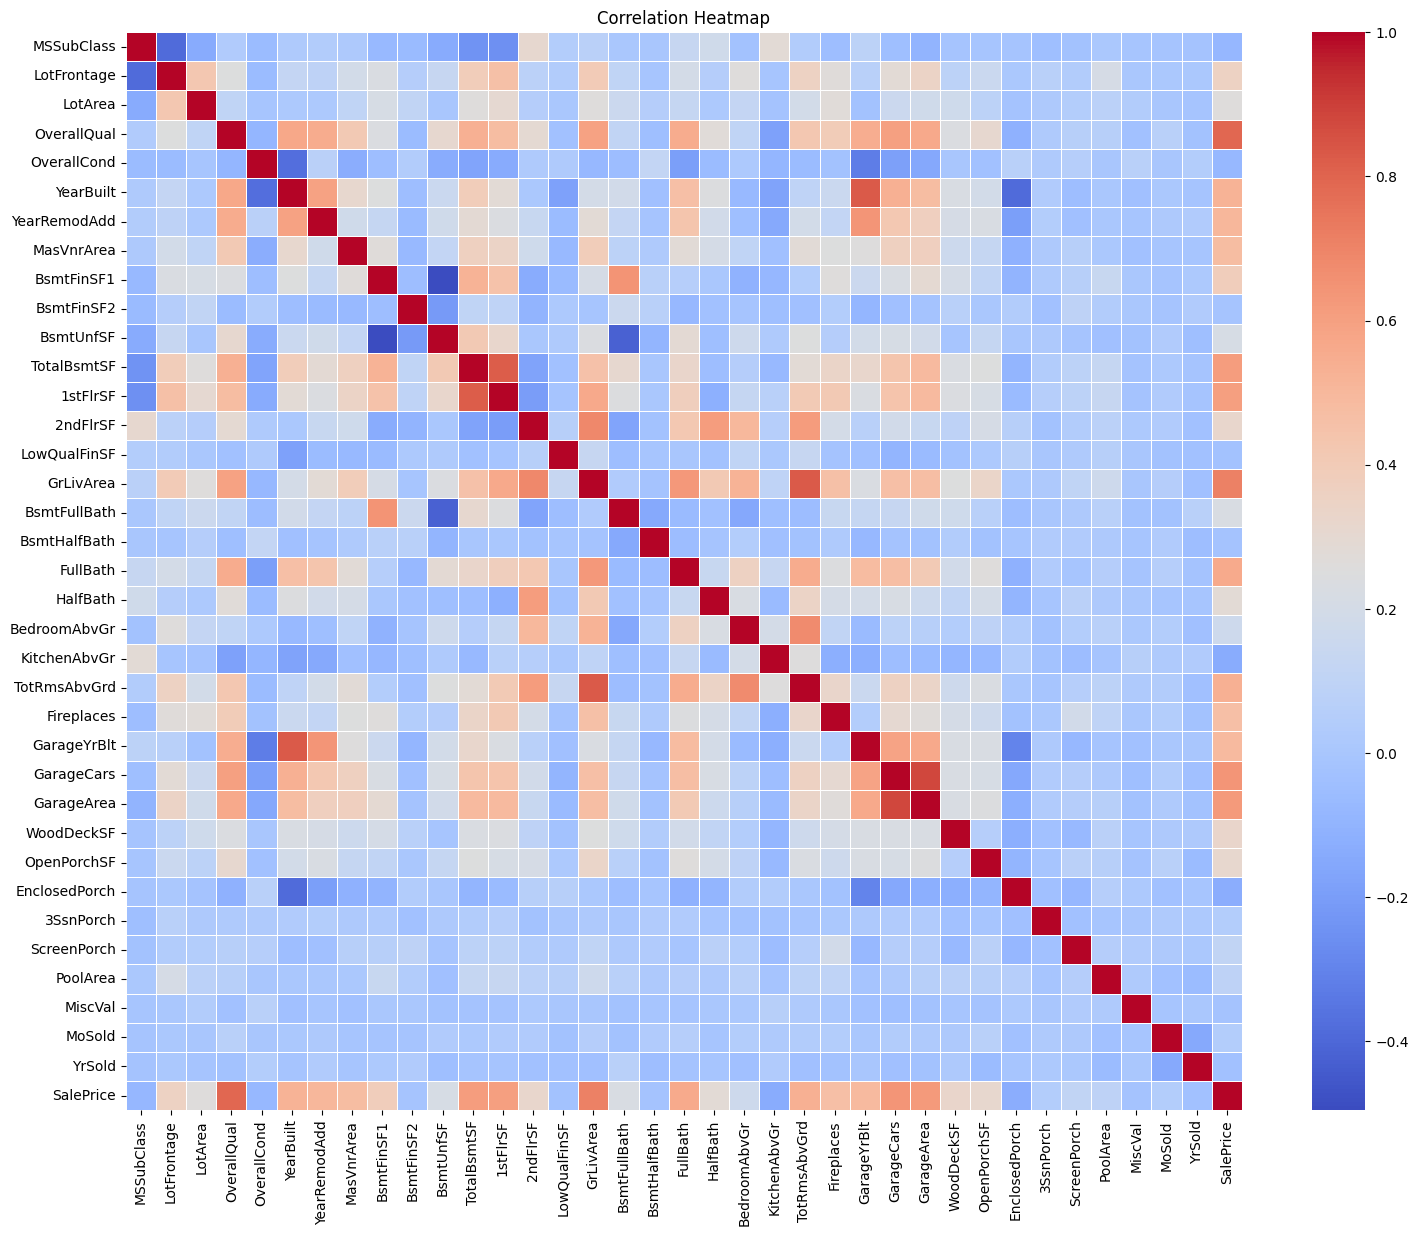

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix (only numerical columns)
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
# Correlation With Target
corr = corr_matrix["SalePrice"].sort_values()
print(corr)

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePrice, dtype: float64


In [37]:
# Drop low correlation columns
corr=df.corr(numeric_only=True)["SalePrice"]

low_corr_cols=corr[(corr>-0.05) & (corr<0.05)].index

print(low_corr_cols)

df.drop(columns=low_corr_cols, inplace=True)

Index(['BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')


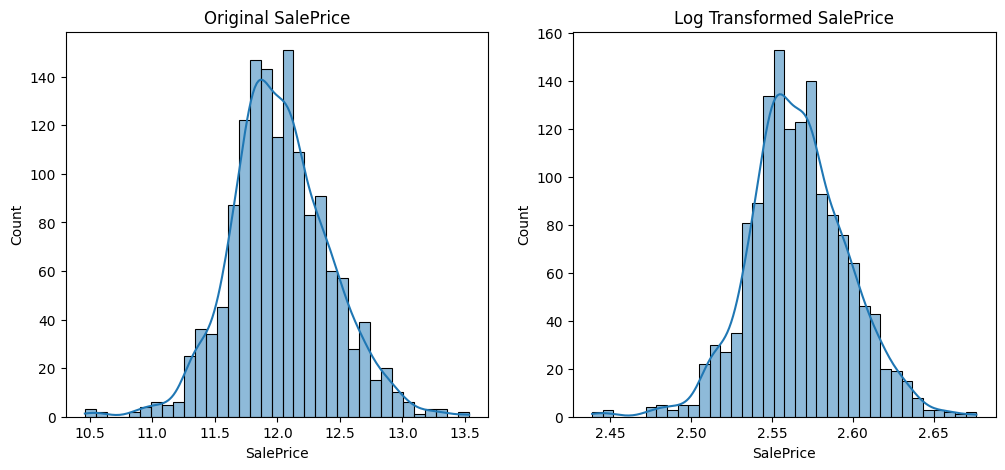

In [38]:
# Target Transformation
df["SalePrice"] = np.log1p(df["SalePrice"])

# Target Transformation Visualization
plt.figure(figsize=(12,5))

#Before
plt.subplot(1,2,1)
sns.histplot(df["SalePrice"], kde=True) #type:ignore
plt.title("Original SalePrice")

# After
plt.subplot(1,2,2)
sns.histplot(np.log1p(df["SalePrice"]), kde=True)
plt.title("Log Transformed SalePrice")

plt.show()

In [39]:
# Separate Features and Target
X=df.drop("SalePrice", axis=1)
y=df["SalePrice"]

In [40]:
# Numerical and Categorical Columns
num_cols=X.select_dtypes(include=["int64", "float64"]).columns

cat_cols=X.select_dtypes(include=["object", "string", "category"]).columns

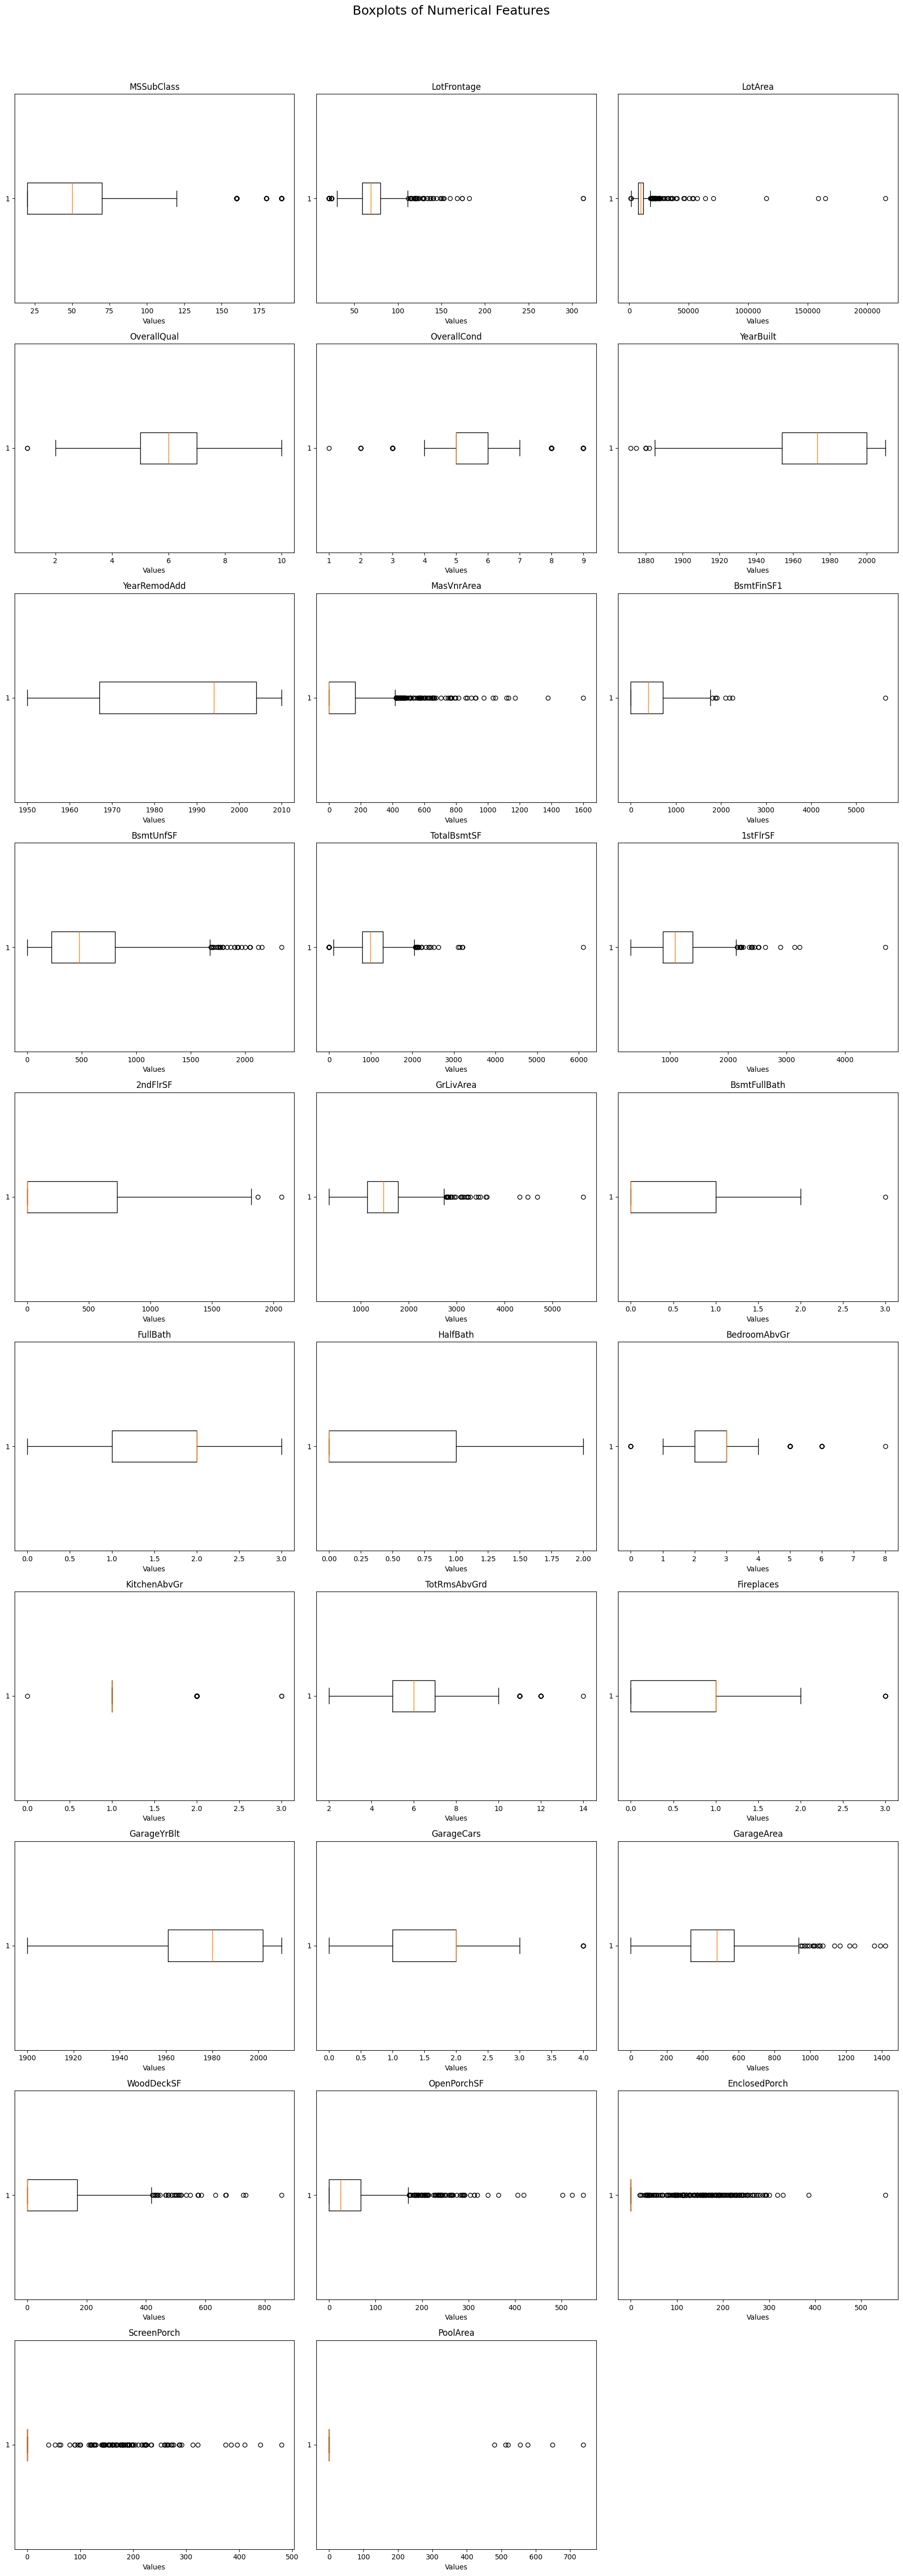

In [42]:
### Detect Outliers
# Layout settings
import math
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)
axes = axes.flatten()
# Create boxplots
for i, col in enumerate(num_cols):
    axes[i].boxplot(
        X[col].dropna(),
        vert=False
    )

    axes[i].set_title(
        col,
        fontsize=12
    )
    
    axes[i].set_xlabel("Values")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle(
    "Boxplots of Numerical Features",
    fontsize=18,
    y=1.02
)
# Adjust spacing
plt.tight_layout()
# Show plot
plt.show()



## Preprocessing Pipelines

In [13]:
# Numerical Pipeline
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor=ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [14]:
# Train / Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2,
    random_state=42
)

## Linear Regression

In [15]:
linear_model=Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
linear_model.fit(X_train, y_train)

#Predict
linear_pred=linear_model.predict(X_test)

pred_real_linear = np.expm1(linear_pred) # real prediction
y_test_real = np.expm1(y_test) # real test dataset target

# Evaluation
lin_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_linear))
lin_mae=mean_absolute_error(y_test_real, pred_real_linear)
lin_r2=r2_score(y_test_real, pred_real_linear)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression MAE:", lin_mae)
print("Linear Regression R2:", lin_r2)

Linear Regression RMSE: 22867.19422712427
Linear Regression MAE: 14949.1232212147
Linear Regression R2: 0.9318270751860517


## Decision Tree

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
pred_real_dt = np.expm1(y_pred_dt) # real prediction

# Evaluation
dt_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_dt))
dt_mae=mean_absolute_error(y_test_real, pred_real_dt)
dt_r2=r2_score(y_test_real, pred_real_dt)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree MAE:", dt_mae)
print("Decision Tree R2:", dt_r2)

Decision Tree RMSE: 31957.477643694772
Decision Tree MAE: 22774.359441429635
Decision Tree R2: 0.8668530712044155


## Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
pred_real_rf = np.expm1(y_pred_rf) # real prediction

# Evaluation
rf_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_rf))
rf_mae=mean_absolute_error(y_test_real, pred_real_rf)
rf_r2=r2_score(y_test_real, pred_real_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 29306.219442477744
Random Forest MAE: 17253.09164531058
Random Forest R2: 0.8880289475555929


## Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
pred_real_gb = np.expm1(y_pred_gb) # real prediction

# Evaluation
gb_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_gb))
gb_mae=mean_absolute_error(y_test_real, pred_real_gb)
gb_r2=r2_score(y_test_real, pred_real_gb)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting RMSE: 29524.36028338474
Gradient Boosting MAE: 16459.66195381376
Gradient Boosting R2: 0.8863558306912253


## KNN Regressor

In [19]:
from sklearn.neighbors import KNeighborsRegressor

knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(
        n_neighbors=5
    ))
])

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
pred_real_knn = np.expm1(y_pred_knn) # real prediction

# Evaluation
knn_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_knn))
knn_mae=mean_absolute_error(y_test_real, pred_real_knn)
knn_r2=r2_score(y_test_real, pred_real_knn)

print("KNN RMSE:", knn_rmse)
print("KNN MAE:", knn_mae)
print("KNN R2:", knn_r2)

KNN RMSE: 38020.78727532094
KNN MAE: 21612.96220464066
KNN R2: 0.8115360121606444


## SVR

In [20]:
from sklearn.svm import SVR

svr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=100,
        gamma=0.01
    ))
])

svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)
pred_real_svr = np.expm1(y_pred_svr) # real prediction

# Evaluation
svr_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_svr))
svr_mae=mean_absolute_error(y_test_real, pred_real_svr)
svr_r2=r2_score(y_test_real, pred_real_svr)

print("KNN RMSE:", svr_rmse)
print("KNN MAE:", svr_mae)
print("KNN R2:", svr_r2)

KNN RMSE: 28557.80907540044
KNN MAE: 17093.69427690363
KNN R2: 0.8936748663410363


## Bagging Regressor

In [21]:
from sklearn.ensemble import BaggingRegressor

bag = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
pred_real_bag = np.expm1(y_pred_bag) # real prediction

# Evaluation
bag_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_bag))
bag_mae=mean_absolute_error(y_test_real, pred_real_bag)
bag_r2=r2_score(y_test_real, pred_real_bag)

print("Bagging RMSE:", bag_rmse)
print("Bagging MAE:", bag_mae)
print("Bagging R2:", bag_r2)

Bagging RMSE: 29044.809430931713
Bagging MAE: 17398.56644856762
Bagging R2: 0.8900175908961105


## Extra Trees

In [22]:
from sklearn.ensemble import ExtraTreesRegressor

extra = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

extra.fit(X_train, y_train)

y_pred_extra = extra.predict(X_test)
pred_real_extra = np.expm1(y_pred_extra) # real prediction

# Evaluation
extra_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_extra))
extra_mae=mean_absolute_error(y_test_real, pred_real_extra)
extra_r2=r2_score(y_test_real, pred_real_extra)

print("Extra Trees RMSE:", extra_rmse)
print("Extra Trees MAE:", extra_mae)
print("Extra Trees R2:", extra_r2)

Extra Trees RMSE: 28065.044801949698
Extra Trees MAE: 17025.347604131384
Extra Trees R2: 0.8973124847027477


## Voting Regressor

In [23]:
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor([
    ("rf", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )),
    ("gb", GradientBoostingRegressor(
        random_state=42
    )),
    ("extra", ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ))
])

voting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", voting)
])

voting_model.fit(X_train, y_train)

y_pred_vote = voting_model.predict(X_test)
pred_real_vote = np.expm1(y_pred_vote) # real prediction

# Evaluation
vote_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_vote))
vote_mae=mean_absolute_error(y_test_real, pred_real_vote)
vote_r2=r2_score(y_test_real, pred_real_vote)

print("Voting Regressor RMSE:", vote_rmse)
print("Voting Regressor MAE:", vote_mae)
print("Voting Regressor R2:", vote_r2)

Voting Regressor RMSE: 28728.086873286036
Voting Regressor MAE: 16399.664079803286
Voting Regressor R2: 0.8924031451718759


## Stacking

In [24]:
from sklearn.ensemble import StackingRegressor

# Base models
estimators=[
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )), 
    ("gb", GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )),
    ("extra", ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))    
]

# Stacking model
stack_model=Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingRegressor(
        estimators=estimators, 
        #Final model
        final_estimator=LinearRegression(),
        n_jobs=-1
    ))
])

# Train 
stack_model.fit(X_train, y_train)

# Predict
stack_pred=stack_model.predict(X_test)
pred_real_stack = np.expm1(stack_pred) # real prediction

# Evaluation
stack_rmse=np.sqrt(mean_squared_error(y_test_real, pred_real_stack))
stack_mae=mean_absolute_error(y_test_real, pred_real_stack)
stack_r2=r2_score(y_test_real, pred_real_stack)

print("Stacking RMSE:", stack_rmse)
print("Stacking MAE:", stack_mae)
print("Stacking R2:", stack_r2)

Stacking RMSE: 27830.96278382334
Stacking MAE: 15833.992815485059
Stacking R2: 0.8990183117963365


## Compare Predictions

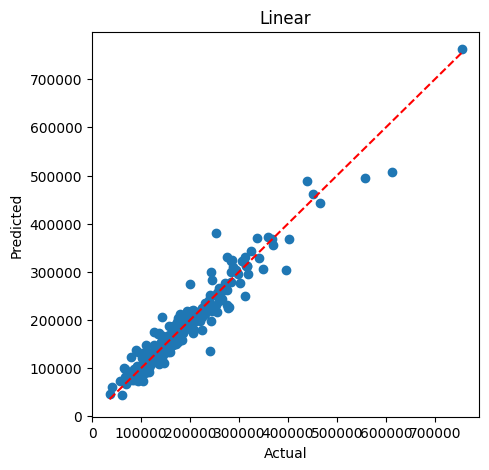

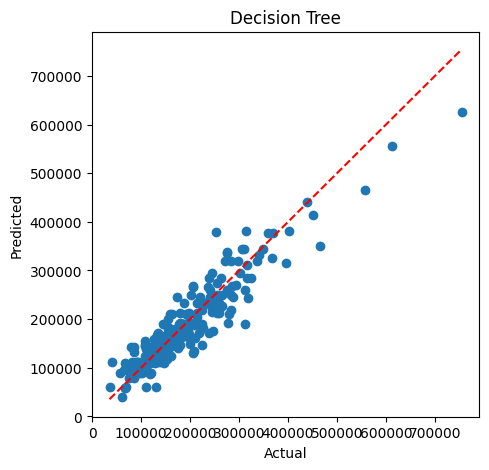

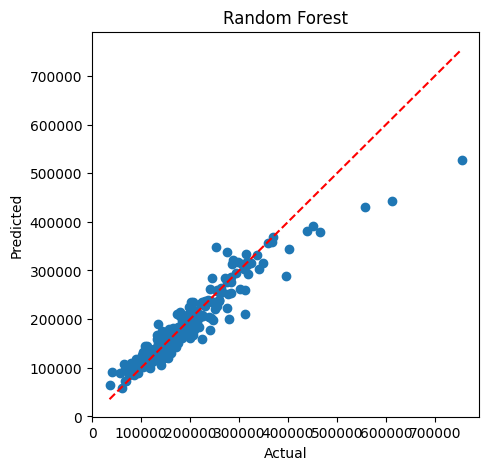

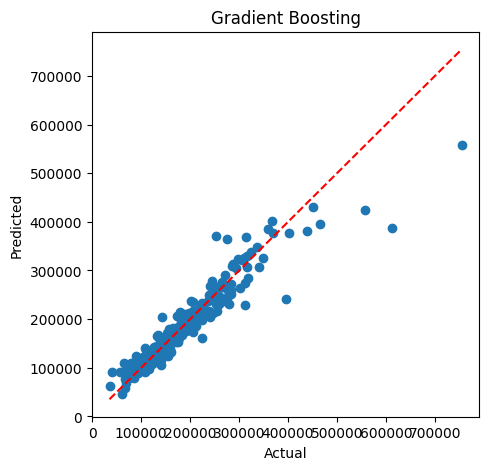

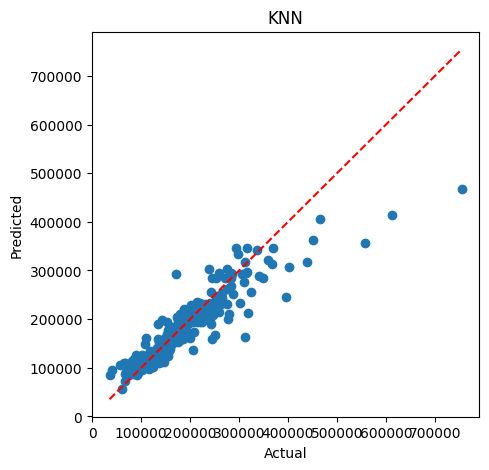

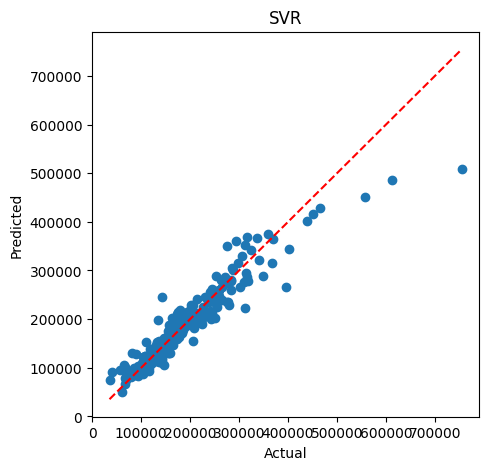

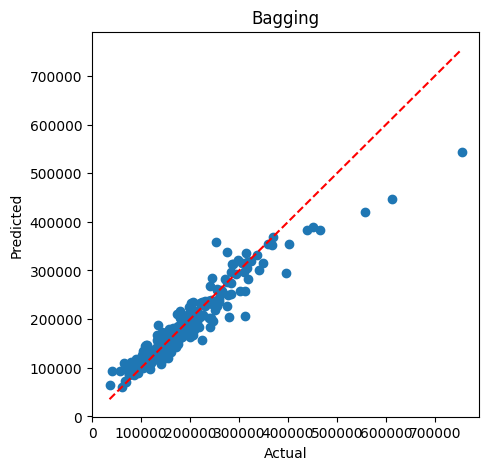

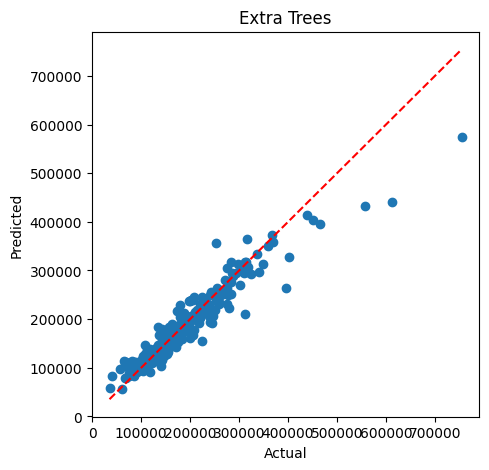

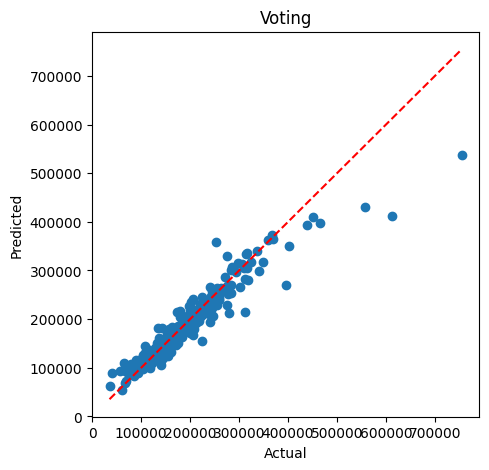

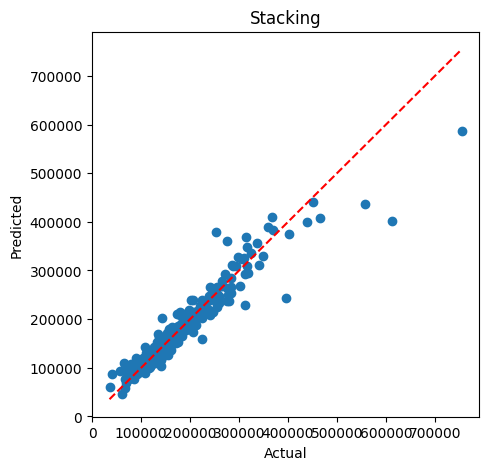

In [25]:
models = {
    "Linear": linear_model,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "KNN": knn,
    "SVR": svr,
    "Bagging": bag,
    "Extra Trees": extra,
    "Voting": voting_model,
    "Stacking": stack_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(5,5))
    plt.scatter(y_test_real, np.expm1(y_pred))
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(name)

    plt.plot(
        [y_test_real.min(), y_test_real.max()],
        [y_test_real.min(), y_test_real.max()],
        "r--"
    )
    plt.show()

## Comparison Table

In [26]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_real, np.expm1(y_pred))
    results[name] = r2

for name, score in results.items():
    print(f"{name}: {score:.4f}")

Linear: 0.9318
Decision Tree: 0.8669
Random Forest: 0.8880
Gradient Boosting: 0.8864
KNN: 0.8115
SVR: 0.8937
Bagging: 0.8900
Extra Trees: 0.8973
Voting: 0.8924
Stacking: 0.8990


## Bar Chart Comparison

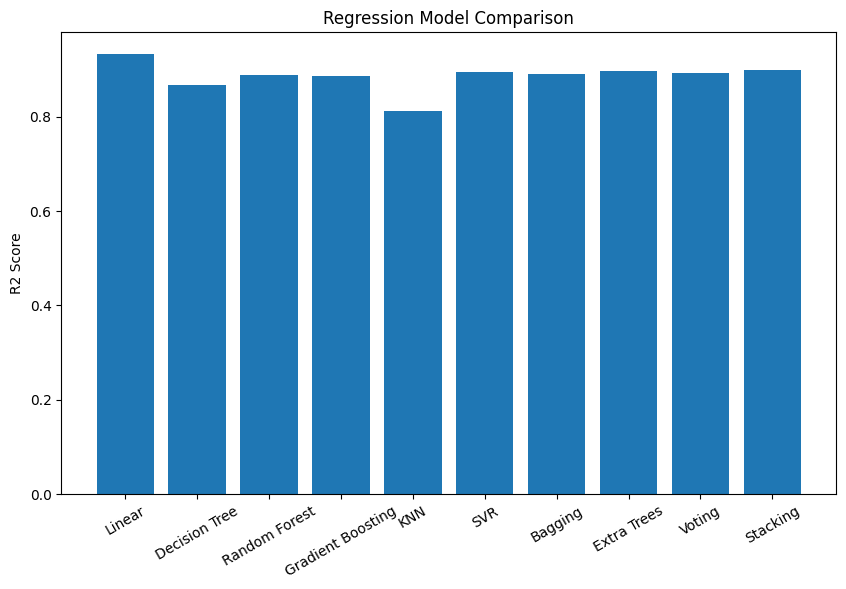

In [27]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values()) #type:ignore
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison")
plt.show()